<a href="https://colab.research.google.com/github/HoaiNam2k5/Deep_Learning_Practice/blob/main/Lab02_Heart_Rate_Prediction_with_TensorFlow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
import pickle
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

## Bước 1: Thiết lập và Nạp dữ liệu
Nhập các thư viện cần thiết (`pandas`, `numpy`, `tensorflow`, `sklearn`) và tải tập dữ liệu nhịp tim từ URL.

In [13]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import pickle
import tensorflow as tf

# Define target column globally
TARGET_COL = '-.2' # From current dataframe state

# Step 1: Load data
url = 'https://raw.githubusercontent.com/huynhhoc/DataAnalystDeepLearning/main/Data/patient_heart_rate.csv'
df = pd.read_csv(url)
display(df.head())

,1,Mickéy Mousé,56,70kgs,72,69,71,-,-.1,-.2
0,2.0,Donald Duck,34.0,154.89lbs,-,-,-,85,84,76
1,3.0,Mini Mouse,16.0,NaN,-,-,-,65,69,72
2,4.0,Scrooge McDuck,NaN,78kgs,78,79,72,-,-,-
3,5.0,Pink Panther,54.0,198.658lbs,-,-,-,69,NaN,75
4,6.0,Huey McDuck,52.0,189lbs,-,-,-,68,75,72


## Bước 2: Làm sạch và Tiền xử lý dữ liệu
Thực hiện loại bỏ dữ liệu trùng lặp, xử lý giá trị thiếu (NaN) bằng median/mode, lọc ngoại lệ (outliers) bằng phương pháp IQR và mã hóa các cột phân loại.

In [14]:
# Step 2: Data Cleaning
# 2.1 Drop duplicates
df = df.drop_duplicates()

# 2.2 Fill NaN
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

# 2.3 Remove outliers using IQR (excluding target column)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != TARGET_COL]

Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1
df = df[~((df[numeric_cols] < (Q1 - 1.5 * IQR)) | (df[numeric_cols] > (Q3 + 1.5 * IQR))).any(axis=1)]

# 2.4 Label Encoding (Saving encoders in a dict)
le_dict = {}
for col in df.select_dtypes(include=['object']).columns:
    le_dict[col] = LabelEncoder()
    df[col] = le_dict[col].fit_transform(df[col])

print("Cleaning complete. Data shape:", df.shape)

Cleaning complete. Data shape: (13, 10)


## Bước 3: Chia tập dữ liệu Train/Test
Tách dữ liệu thành các biến độc lập (X) và mục tiêu (y), sau đó chia thành tập huấn luyện và tập kiểm tra theo tỉ lệ 80/20.

In [15]:
# Step 3 & 4: Train/Test Split and Scaling
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and fit scaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data split and scaled successfully.")

Data split and scaled successfully.


## Bước 4: Chuẩn hóa dữ liệu và Lưu trữ Scaler
Sử dụng `StandardScaler` để chuẩn hóa dữ liệu. Lưu đối tượng scaler vào file `scaler.pkl` để sử dụng cho việc dự đoán sau này.

In [5]:
# Step 5a: Save Scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("Scaler saved to scaler.pkl")

Scaler saved to scaler.pkl


## Bước 5: Khởi tạo TensorFlow Dataset
Chuyển đổi dữ liệu từ Numpy sang `tf.data.Dataset`, thiết lập shuffle và batch size để tối ưu hiệu suất nạp dữ liệu vào mô hình.

In [6]:
# Step 5b: Create TF Datasets
def create_dataset(X, y, batch_size=32, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(X))
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

train_dataset = create_dataset(X_train_scaled, y_train)
test_dataset = create_dataset(X_test_scaled, y_test, shuffle=False)

print("TensorFlow Datasets ready.")

TensorFlow Datasets ready.


## Bước 6: Xây dựng cấu trúc Mô hình Sequential
Thiết lập mạng nơ-ron đa tầng với các lớp Dense và hàm kích hoạt ReLU, cấu hình bộ tối ưu hóa Adam và hàm mất mát MSE.

In [7]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,753 (10.75 KB)

 Trainable params: 2,753 (10.75 KB)

 Non-trainable params: 0 (0.00 B)

## Bước 7: Huấn luyện Mô hình
Tiến hành huấn luyện mô hình với 100 epochs dựa trên tập dữ liệu đã chuẩn bị.

In [16]:
# Step 7: Train with EarlyStopping
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    train_dataset,
    epochs=100,
    validation_data=test_dataset,
    callbacks=[early_stop]
)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0027 - mae: 0.0310 - val_loss: 0.2446 - val_mae: 0.4220
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0026 - mae: 0.0306 - val_loss: 0.2423 - val_mae: 0.4204
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 0.0025 - mae: 0.0301 - val_loss: 0.2398 - val_mae: 0.4186
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0025 - mae: 0.0296 - val_loss: 0.2370 - val_mae: 0.4167
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - loss: 0.0024 - mae: 0.0290 - val_loss: 0.2342 - val_mae: 0.4147
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.0023 - mae: 0.0284 - val_loss: 0.2312 - val_mae: 0.4126
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0022 - mae: 0.0279 - val_loss: 0.2283 - val_mae: 0.4106
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0022 - mae: 0.0274 - val_loss: 0.2254 - val_mae: 0.4086
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0021 - mae: 

## Bước 8: Đánh giá kết quả dự đoán
Đo lường sai số MSE/MAE trên tập kiểm tra và so sánh trực quan giữa giá trị thực tế và giá trị dự đoán từ mô hình.

In [17]:
from sklearn.metrics import r2_score

loss, mae = model.evaluate(test_dataset)
print(f"Validation Loss (MSE): {loss:.4f}")
print(f"Validation MAE: {mae:.4f}")

# Predictions and R2
predictions = model.predict(X_test_scaled)
print(f"R² Score: {r2_score(y_test, predictions):.4f}")

for i in range(len(predictions)):
    print(f"Thực tế: {y_test.iloc[i]}, Dự đoán: {predictions[i][0]:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1809 - mae: 0.3739
Validation Loss (MSE): 0.1809
Validation MAE: 0.3739
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
R² Score: 0.9491
Thực tế: 0, Dự đoán: 0.50
Thực tế: 0, Dự đoán: -0.09
Thực tế: 4, Dự đoán: 4.53


## Bước 8.1: Trực quan hóa kết quả
Vẽ biểu đồ đường cho quá trình huấn luyện và biểu đồ scatter để so sánh giá trị thực tế với dự đoán.

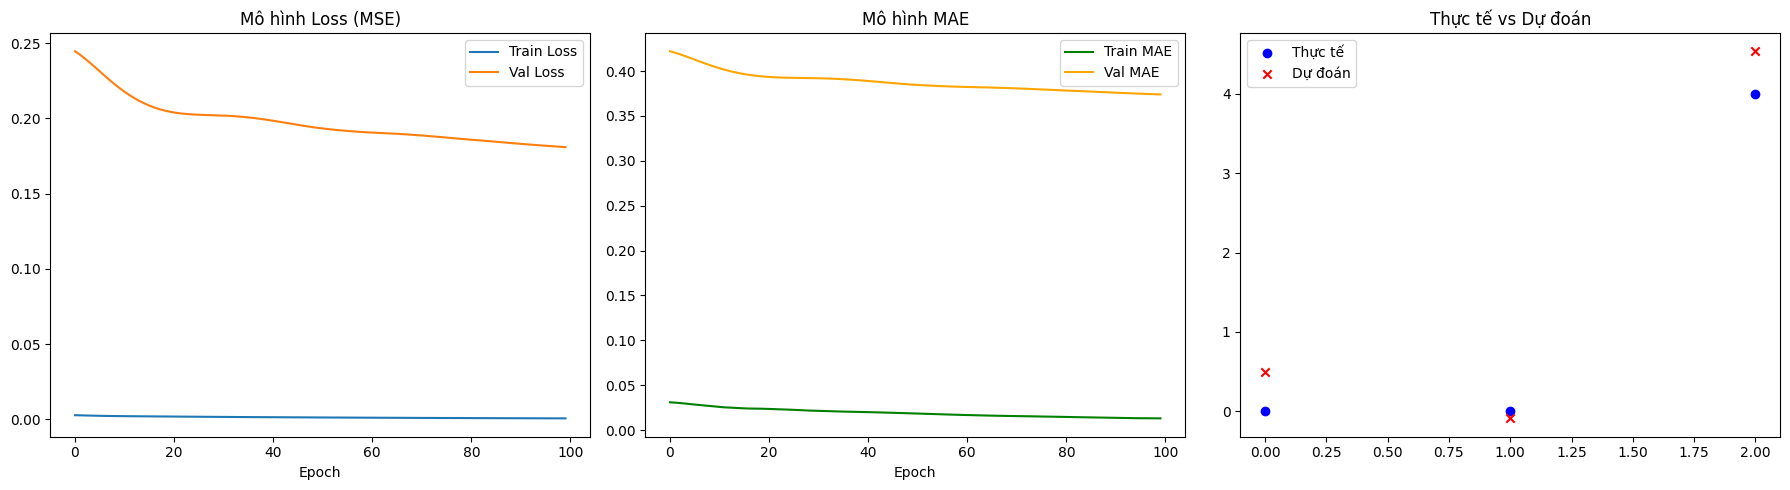

In [18]:
import matplotlib.pyplot as plt

# Create figure with 3 subplots
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# 1. Loss Chart
ax1.plot(history.history['loss'], label='Train Loss')
ax1.plot(history.history['val_loss'], label='Val Loss')
ax1.set_title('Mô hình Loss (MSE)')
ax1.set_xlabel('Epoch')
ax1.legend()

# 2. MAE Chart
ax2.plot(history.history['mae'], label='Train MAE', color='green')
ax2.plot(history.history['val_mae'], label='Val MAE', color='orange')
ax2.set_title('Mô hình MAE')
ax2.set_xlabel('Epoch')
ax2.legend()

# 3. Actual vs Predicted
ax3.scatter(range(len(y_test)), y_test, color='blue', label='Thực tế')
ax3.scatter(range(len(predictions)), predictions, color='red', label='Dự đoán', marker='x')
ax3.set_title('Thực tế vs Dự đoán')
ax3.legend()

plt.tight_layout()
plt.show()

## Bước 9: Lưu trữ Mô hình cuối cùng
Lưu mô hình đã huấn luyện thành file `heart_rate_model.keras` để triển khai hoặc sử dụng lại.

In [10]:
model.save('heart_rate_model.keras')
print("Model đã được lưu thành công!")

Model đã được lưu thành công!
